# PyEarthTool BARRA2 tutorial
This notebook will be used to load, transform and plot BARRA2 data with PyEarthTools (PET).
The aim is to showcase the implementation of BARRA2 in PET and how to match BARRA-RE2 to ERA5.
At the end of this notebook we will have:
- loaded BARRA-R2 and ERA5 data,
- combined hourly instantaneous and hourly averaged variables into a single dataset,
- regridded ERA5 to BARRA-R2 resolution,
- plotted BARRA-R2 time means on a map and compared them against ERA5,
- plotted and compared BARRA-R2 and ERA5 in histograms.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import dask.distributed
import cartopy.crs as ccrs

# Load PET specific modules and NCI settings
import pyearthtools
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci

import warnings
warnings.filterwarnings('ignore')

Start a dask client to help with faster processing.

In [2]:
client = dask.distributed.Client(n_workers = 25, threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 25
Total threads: 25,Total memory: 251.19 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42963,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:44843,Total threads: 1
Dashboard: /proxy/35559/status,Memory: 10.05 GiB
Nanny: tcp://127.0.0.1:33803,


2025-10-10 15:50:06,524 - distributed.scheduler - WARNING - Detected different `run_spec` for key ('where-getitem-44ee83ba71035d1c16fab2ee0d26a64d', 1, 0, 0, 0) between two consecutive calls to `update_graph`. This can cause failures and deadlocks down the line. Please ensure unique key names. If you are using a standard dask collections, consider releasing all the data before resubmitting another computation. More details and help can be found at https://github.com/dask/dask/issues/9888. 
Debugging information
---------------------
old task state: released
old run_spec: <Task ('where-getitem-44ee83ba71035d1c16fab2ee0d26a64d', 1, 0, 0, 0) _execute_subgraph(...)>
new run_spec: <Task ('where-getitem-44ee83ba71035d1c16fab2ee0d26a64d', 1, 0, 0, 0) _execute_subgraph(...)>
old dependencies: {('array-1defe82f28400b0bc9287e918e13ce36', 0, 0, 0, 0), ('eq-76cf084d4035f655357dfe14cabd9f85', 0, 0, 0, 0), ('array-4e137fb0017e1888354c77ed7340d853', 1, 0, 0, 0), ('array-4bdd9cbd06fcdea45fac05402c2306

### Load some BARRA-R2 and ERA5 data

This builds an accessor, called barra2 and era5, that can be indexed by time, filtered according to the specified parameters. Here we want to look at a list of variables.

For BARRA2, we need to create two variable lists, and two accessors, because some fields are instantaneous (e.g., tas) and are valid at full hours (e.g., 01:00), while others represent hourly averages (e.g., pr) and have a valid time at half hours (e.g., 00:30).

In [3]:
varlist_hourly_instant = [
    'tas', # surface temperature
    'ta500', # temperature at 500hPa
    'uas', # 10m u-winds
    'ua500', # u-wind at 500hPa
    'vas', # 10m v-winds
    'va500', # v-winds at 500hPa
    'omega500', # pressure velocity at 500hPa
    'hus500', # specific humidity at 500hPa
    'psl', # mean sea level pressure
    'prw', # water vapour path,
    'zg500', # geopotential at 500hPa
]

varlist_hourly_averaged = [
    'pr', # hourly average precipitation
    'clt', # hourly average cloud cover
    'rsdt', # hourly average TOA Incident Shortwave Radiation
    'rsds', # hourly average shortwave down surface
    'rsut', # hourly average TOA outgoing shortwave
    'rlus', # hourly averaged longwave up surface
    'rlds', # hourly average longwave down surface
    'rlut', # hourly average TOA outgoing longwave
]

# The full varlist is
varlist = varlist_hourly_instant + varlist_hourly_averaged

Now create an accessor for BARRA-R2.

In [4]:
barra2_hinstant = petdata.archive.BARRA_V2(varlist_hourly_instant, domain_id='AUS-11', frequency='1hr')
barra2_haveraged = petdata.archive.BARRA_V2(varlist_hourly_averaged, domain_id='AUS-11', frequency='1hr')

To open the same variables with ERA5, we need a mapping from the names in BARRA2 to ERA5

In [5]:
barra2era_map = {
    'tas': '2t',
    'ta500': 't',
    'uas': 'u10n',
    'ua500': 'u',
    'vas': 'v10n',
    'va500': 'v',
    'omega500': 'w',
    'hus500': 'q',
    'ps': 'sp',
    'psl': 'msl',
    'prw': 'tcw',
    'pr': 'tp',
    'clt': 'tcc',
    'zg500': 'z',
    # following https://www.ecmwf.int/sites/default/files/elibrary/2015/18490-radiation-quantities-ecmwf-model-and-mars.pdf
    'rsdt': 'tisr', # J m-2
    'rsds': 'ssrd', # J m-2
    'rsut': 'tsr', # tisr - tsr, J m-2
    'rlus': 'str', # strd - str, J m-2
    'rlds': 'strd', # J m-2
    'rlut': 'ttr', # J m-2
}

Now create an accessor for ERA5.

In [6]:
era5 = petdata.archive.ERA5([barra2era_map[key] for key in varlist], product='reanalysis')

Now that we have our accessors, lets extract a years worth of data and compare ERA5 and BARRA2

In [7]:
ds_barra2_hinstant = barra2_hinstant.series('2000-01-01', '2000-01-31T23', interval = (1, 'hour'))
ds_barra2_haveraged = barra2_haveraged.series('2000-01-01', '2000-01-31T23', interval = (1, 'hour'))
# # Some BARRA2 fields have a single length heigh dimension. We do not want this.
try:
    ds_barra2_hinstant = ds_barra2_hinstant.mean('height')
    ds_barra2_haveraged = ds_barra2_haveraged.mean('height')
except:
    pass

Now that we have both instantaneous and hourly averaged fields, we resample the averaged values to hourly values valid at the same time as the instantaneous fields.

Then we combine them in one dataset.

Because the first time step in the averaged fields is 00:30, when interpolated the new first time step (i.e., 00:00) will be NaN. We drop the first time step after resampling to avoid this.

In [8]:
ds_barra2_haveraged = ds_barra2_haveraged.resample(dict(time="1H")).interpolate('linear')
ds_barra2 = xr.merge([ds_barra2_hinstant, ds_barra2_haveraged])
ds_barra2 = ds_barra2.drop_isel(time=0)
ds_barra2 = ds_barra2.squeeze()

# Rename some variables for ease later
# When we want to use more pressure levels this might have to be dealt 
# with in a smarter way...
ds_barra2 = ds_barra2.rename({
    'ta': 'ta500',
    'ua': 'ua500',
    'va': 'va500',
    'omega': 'omega500',
    'hus': 'hus500',
    'zg': 'zg500',
})
ds_barra2

<xarray.Dataset> Size: 79GB
Dimensions:    (time: 742, longitude: 1082, latitude: 646, bnds: 2)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2000-01-01T01:00:00 ... 2000-01-31T2...
  * longitude  (longitude) float64 9kB 88.48 88.59 88.7 ... 207.2 207.3 207.4
  * latitude   (latitude) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
    crs        int32 4B 0
    pressure   float64 8B 500.0
  * bnds       (bnds) float64 16B 0.0 1.0
Data variables: (12/19)
    uas        (time, latitude, longitude) float64 4GB dask.array<chunksize=(61, 392, 668), meta=np.ndarray>
    hus500     (time, latitude, longitude) float64 4GB dask.array<chunksize=(61, 396, 660), meta=np.ndarray>
    omega500   (time, latitude, longitude) float64 4GB dask.array<chunksize=(61, 392, 668), meta=np.ndarray>
    va500      (time, latitude, longitude) float64 4GB dask.array<chunksize=(61, 396, 660), meta=np.ndarray>
    prw        (time, latitude, longitude) float64 4GB dask.array<chunksize=(61, 396, 660), meta=np.ndarray>
    ta500      (time, latitude, longitude) float64 4GB dask.array<chunksize=(61, 396, 660), meta=np.ndarray>
    ...         ...
    rlut       (time, latitude, longitude) float64 4GB dask.array<chunksize=(742, 98, 167), meta=np.ndarray>
    clt        (time, latitude, longitude) float64 4GB dask.array<chunksize=(742, 99, 165), meta=np.ndarray>
    rlds       (time, latitude, longitude) float64 4GB dask.array<chunksize=(742, 99, 165), meta=np.ndarray>
    pr         (time, latitude, longitude) float64 4GB dask.array<chunksize=(742, 97, 168), meta=np.ndarray>
    rsut       (time, latitude, longitude) float64 4GB dask.array<chunksize=(742, 99, 165), meta=np.ndarray>
    rlus       (time, latitude, longitude) float64 4GB dask.array<chunksize=(742, 98, 167), meta=np.ndarray>
Attributes: (12/53)
    axiom_version:             0.1.0
    axiom_schemas_version:     0.1.0
    axiom_schema:              cordex-1H.json
    productive_version:        f5a7b55
    variable_version:          v20231001
    Conventions:               CF-1.10, ACDD-1.3
    ...                        ...
    geospatial_lat_min:        -57.97
    geospatial_lat_max:        12.98
    geospatial_lat_units:      degrees_north
    geospatial_lon_min:        88.48
    geospatial_lon_max:        207.39
    geospatial_lon_units:      degrees_east

Now that BARRA2 is opened, we work on ERA5. This is easier, as all fields are on the full hour (e.g., 01:00)

In [9]:
ds_era5 = era5.series('2000-01-01', '2000-01-31T23', interval = (1, 'hour'))
# We also drop the first time step in the ERA5 dataset to match BARRA2
ds_era5 = ds_era5.drop_isel(time=0)
# Some variables have pressure levels in them.
# For now we only want pressure level 500hPa, later this might need to be refined
ds_era5 = ds_era5.sel(level=500)
ds_era5

<xarray.Dataset> Size: 114GB
Dimensions:    (time: 742, latitude: 721, longitude: 1440)
Coordinates:
  * longitude  (longitude) float32 6kB -180.0 -179.8 -179.5 ... 179.5 179.8
  * latitude   (latitude) float32 3kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * time       (time) datetime64[ns] 6kB 2000-01-01T01:00:00 ... 2000-01-31T2...
    level      int32 4B 500
Data variables: (12/19)
    ssrd       (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    tcw        (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    msl        (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    u10n       (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    strd       (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    ttr        (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    ...         ...
    tsr        (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    tcc        (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
    t          (time, latitude, longitude) float64 6GB dask.array<chunksize=(3, 405, 900), meta=np.ndarray>
    w          (time, latitude, longitude) float64 6GB dask.array<chunksize=(3, 405, 900), meta=np.ndarray>
    u          (time, latitude, longitude) float64 6GB dask.array<chunksize=(3, 405, 900), meta=np.ndarray>
    tp         (time, latitude, longitude) float64 6GB dask.array<chunksize=(185, 182, 360), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...

ERA5 and BARRA-R2 have different horizontal resolutions. Lets interpolate ERA5 onto the BARRA-R2 grid. We define a reference grid that we interpolate ERA5 to.
ERA5 also has longitudes from -180 to 180, while BARRA2 goes from 0 to 360. We need to updated ERA5 lons to match BARRA2.

In [10]:
# Define the reference grid
refgrid = ds_barra2.isel(time=0)[varlist[0]].squeeze()

# Sort lons like BARRA2
ds_era5 = ds_era5.assign_coords(longitude=(ds_era5['longitude'] % 360))
ds_era5 = ds_era5.sortby(ds_era5["longitude"])

# Interpolate like BARRA2
ds_era5_regrid = ds_era5.interp_like(refgrid)
ds_era5_regrid

<xarray.Dataset> Size: 77GB
Dimensions:    (time: 742, latitude: 646, longitude: 1082)
Coordinates:
  * time       (time) datetime64[ns] 6kB 2000-01-01T01:00:00 ... 2000-01-31T2...
    level      int32 4B 500
  * latitude   (latitude) float64 5kB -57.97 -57.86 -57.75 ... 12.76 12.87 12.98
  * longitude  (longitude) float64 9kB 88.48 88.59 88.7 ... 207.2 207.3 207.4
Data variables: (12/19)
    ssrd       (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    tcw        (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    msl        (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    u10n       (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    strd       (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    ttr        (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    ...         ...
    tsr        (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    tcc        (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
    t          (time, latitude, longitude) float64 4GB dask.array<chunksize=(3, 646, 1082), meta=np.ndarray>
    w          (time, latitude, longitude) float64 4GB dask.array<chunksize=(3, 646, 1082), meta=np.ndarray>
    u          (time, latitude, longitude) float64 4GB dask.array<chunksize=(3, 646, 1082), meta=np.ndarray>
    tp         (time, latitude, longitude) float64 4GB dask.array<chunksize=(47, 323, 1082), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    license:      Licence to use Copernicus Products: https://apps.ecmwf.int/...
    summary:      ERA5 is the fifth generation ECMWF atmospheric reanalysis o...

## Transformations

The units for some variables between BARRA2 and ERA5 do not match! We need to do some conversions.

In [11]:
# Convert total cloud cover to percent
ds_era5_regrid['tcc'] = ds_era5_regrid['tcc'] * 100.

# Convert metres of precipitation to kg m-2 s-1
ds_era5_regrid['tp'] = ds_era5_regrid['tp'] * 1000 / 3600

# Convert geopotential
ds_era5_regrid['z'] = ds_era5_regrid['z'] / 9.81 # rsdt

# Convert J m-2 to W m-2
ds_era5_regrid['tisr'] = ds_era5_regrid['tisr'] / 3600 # rsdt
ds_era5_regrid['ssrd'] = ds_era5_regrid['ssrd'] / 3600 # rsds
ds_era5_regrid['tsr'] = ds_era5_regrid['tsr'] / 3600 # rsut
ds_era5_regrid['str'] = ds_era5_regrid['str'] / 3600 # rlus
ds_era5_regrid['strd'] = ds_era5_regrid['strd'] / 3600 # rlds
ds_era5_regrid['ttr'] = ds_era5_regrid['ttr'] / (-3600) # rlut

# Use net radiation fields to get some missing components
ds_era5_regrid['tsr'] = ds_era5_regrid['tisr'] - ds_era5_regrid['tsr']
ds_era5_regrid['str'] = ds_era5_regrid['strd'] - ds_era5_regrid['str']

Now that we have:
- resampled, averaged values to the same valid time as instantaneous values,
- ommitted the first time step, which is NaN after resampling,
- regridded, ERA5 to the BARRA-R2 grid,
- converted the ERA5 units to match the ones in BARRA-R2 for each variable,
  
we are ready to plot and compare the monthly mean values.

We also added a bias plot, showing the difference between BARRA-R2 and ERA5, as well as a spatial correlation coefficient, r.

In [12]:
ds_era5_regrid_clim = ds_era5_regrid.mean("time").persist()
ds_barra2_clim = ds_barra2.mean("time").persist()

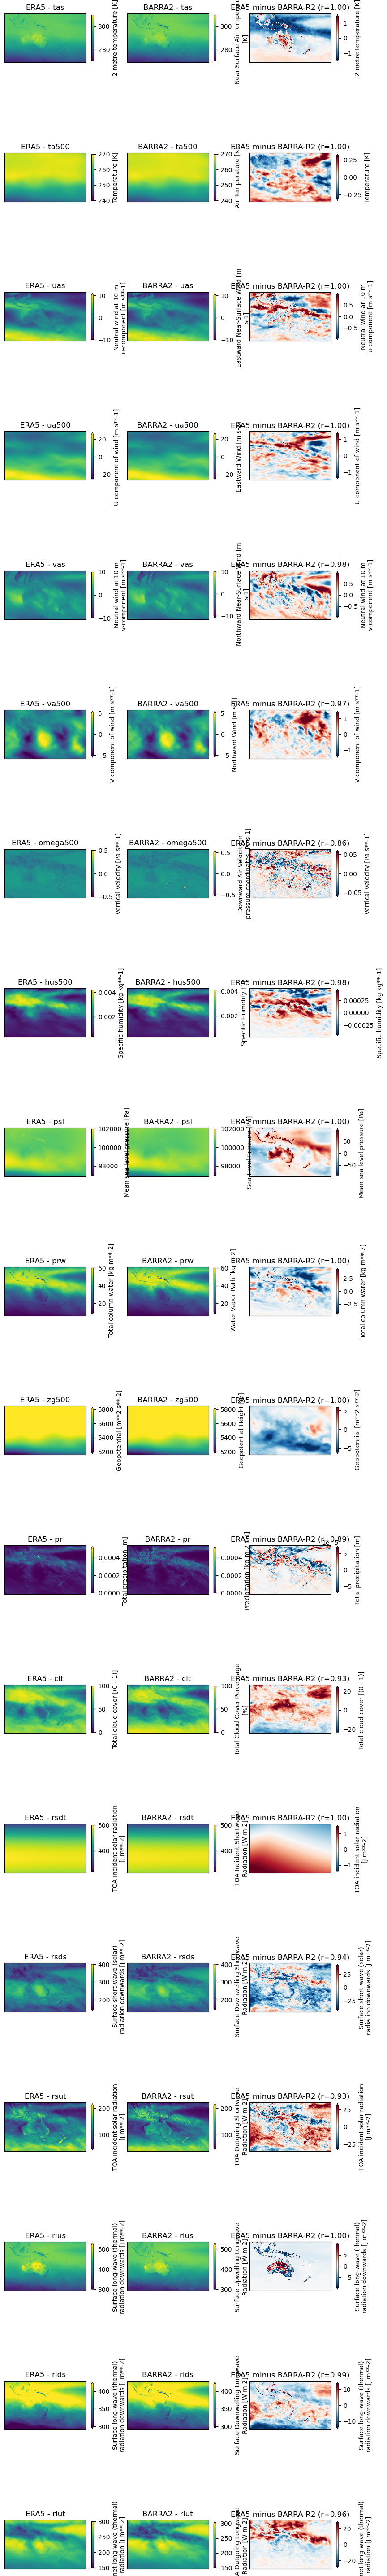

In [13]:
nrows = len(varlist)
fig, axs = plt.subplots(nrows,3, figsize=((10,4*nrows)),subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# Let's define the colour range for easier comparison
vminmax = {
    'tas': (270,310),
    'ta500': (240,270),
    'uas': (-10,10),
    'ua500': (-25,25),
    'vas': (-10,10),
    'va500': (-5,5),
    'omega500': (-0.5,0.5),
    'huss': (None, None),
    'hus500': (None, None),
    'ps': (75000,101000),
    'psl': (97000,102000),
    'prw': (10,60),
    'pr': (0,5e-4),
    'clt': (0,100),
    'rsdt': (320,500),
    'rsds': (150,400),
    'rsut': (50,210),
    'rlus': (300,520),
    'rlds': (300,420),
    'rlut': (150,300),
    'zg500': (5200, 5800),
}

# Plot all variable comparisons
for i, var in enumerate(varlist):
    r = xr.corr(
        ds_era5_regrid_clim[barra2era_map[var]],
        ds_barra2_clim[var]
    ).values
    ds_era5_regrid_clim[barra2era_map[var]].plot.pcolormesh(ax=axs[i,0], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    ds_barra2_clim[var].plot.pcolormesh(ax=axs[i,1], vmin=vminmax[var][0], vmax=vminmax[var][1], transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    (ds_era5_regrid_clim[barra2era_map[var]]-ds_barra2_clim[var]).plot.pcolormesh(ax=axs[i,2], robust=True, transform=ccrs.PlateCarree(), cbar_kwargs=dict(shrink=0.4))
    axs[i,0].set_title(f"ERA5 - {var}")
    axs[i,1].set_title(f"BARRA2 - {var}")
    axs[i,2].set_title(f"ERA5 minus BARRA-R2 (r={r:.2f})")

Now that we have compared the mean maps, lets look at the histograms. For the histograms we do not need the mean values, we can consider the histogram over all hourly values.

For some histograms a log axis is more useful.

2025-10-10 15:50:16,929 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 8.05 GiB -- Worker memory limit: 10.05 GiB
2025-10-10 15:50:17,830 - distributed.worker.memory - WARNING - Worker is at 74% memory usage. Resuming worker. Process memory: 7.46 GiB -- Worker memory limit: 10.05 GiB
2025-10-10 15:50:45,243 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 8.05 GiB -- Worker memory limit: 10.05 GiB
2025-10-10 15:50:45,903 - distributed.worker.memory - WARNING - Worker is at 58% memory usage. Resuming worker. Process memory: 5.88 GiB -- Worker memory limit: 10.05 GiB
2025-10-10 15:51:03,700 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 8.05 GiB -- Worker memory limit: 10.05 GiB
2025-10-10 15:51:04,475 - distributed.worker.memory - WARNING - Worker is at 75% memory usage. Resuming worker. Process memory: 7.62 GiB -- Worke

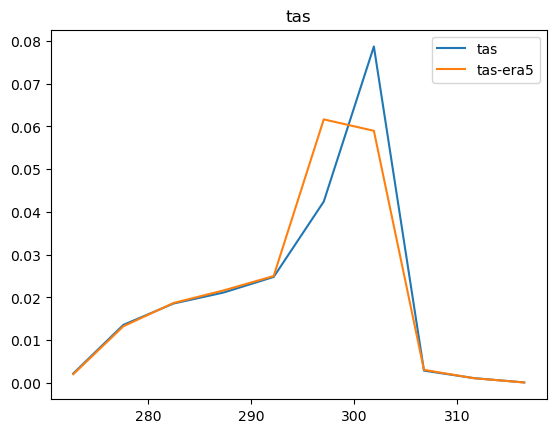

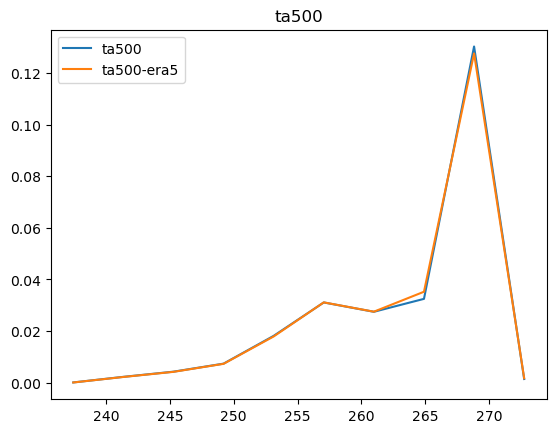

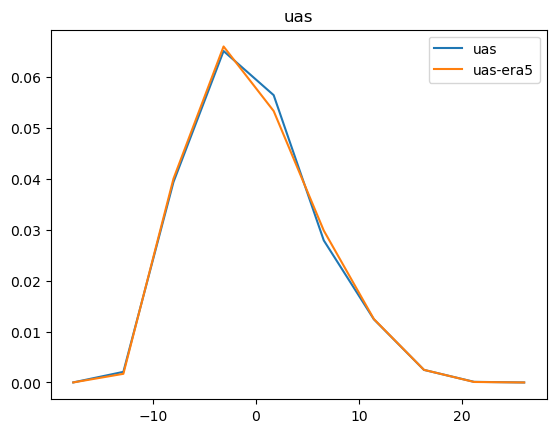

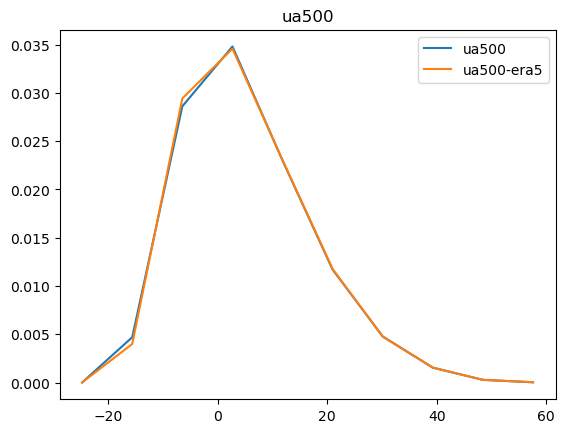

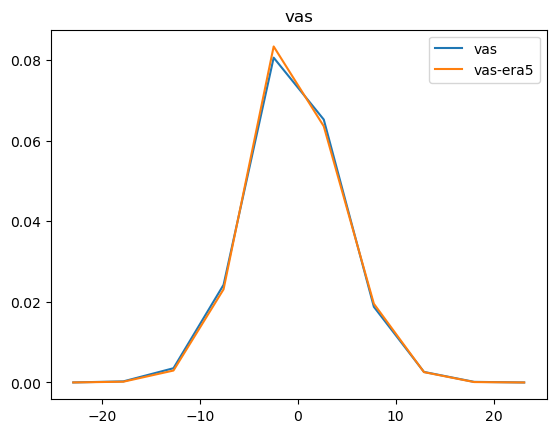

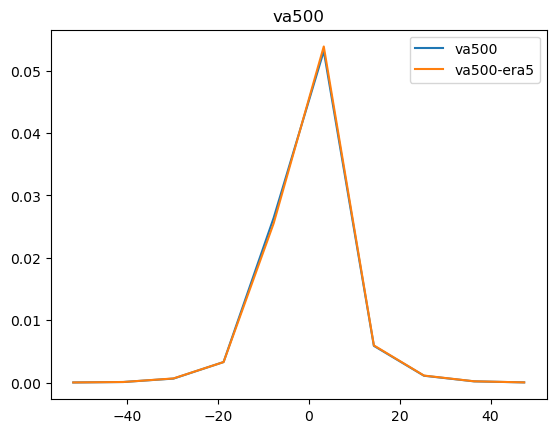

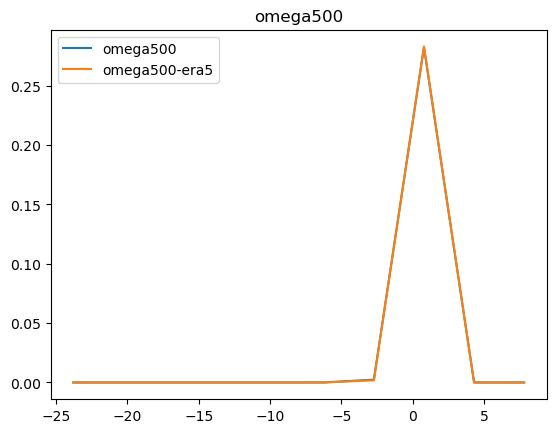

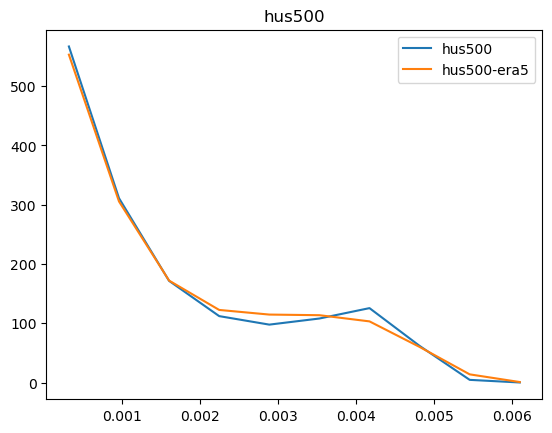

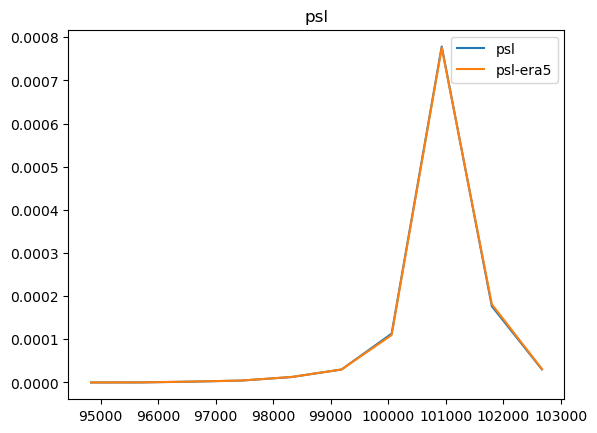

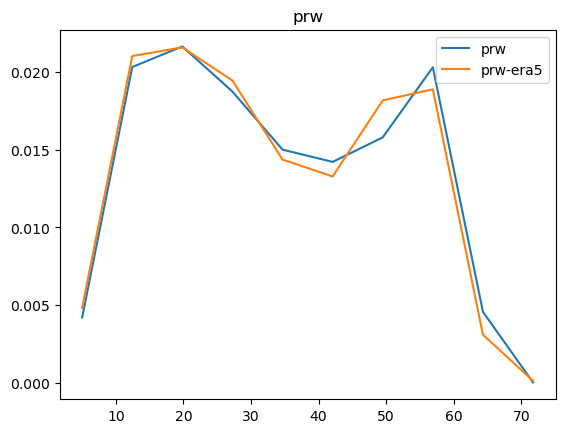

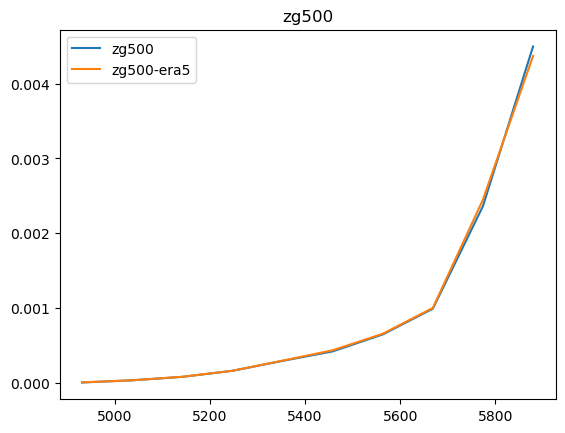

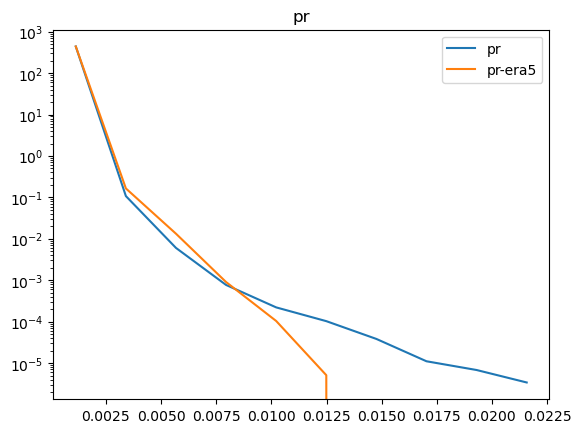

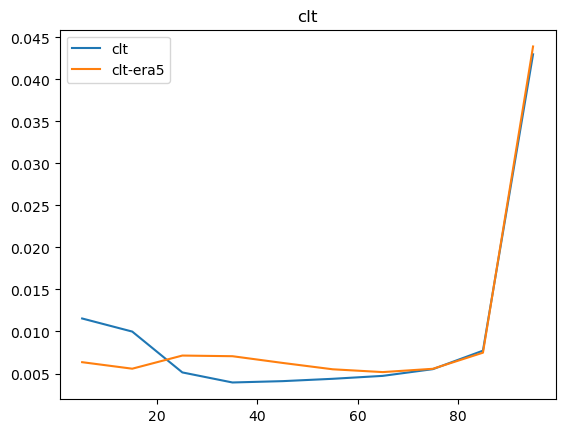

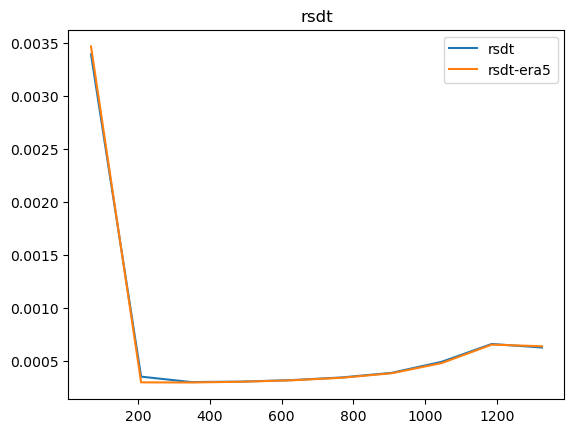

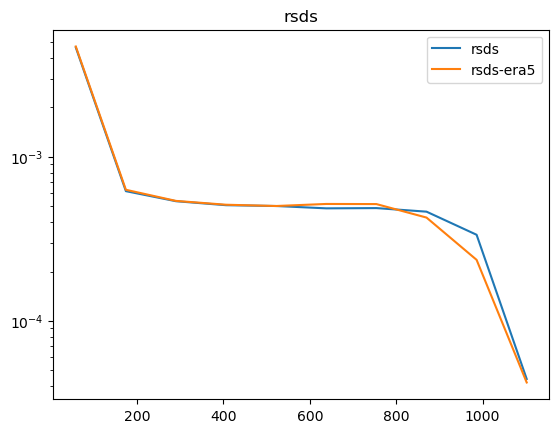

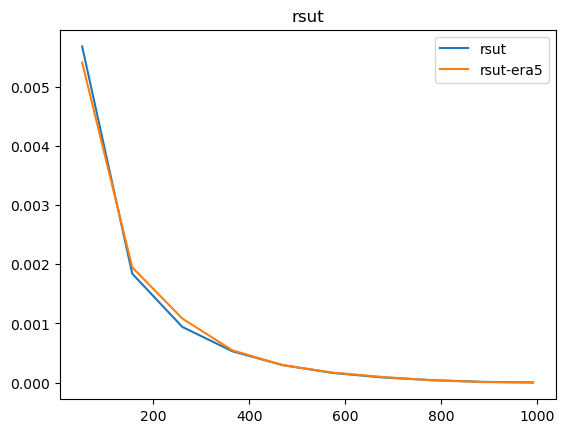

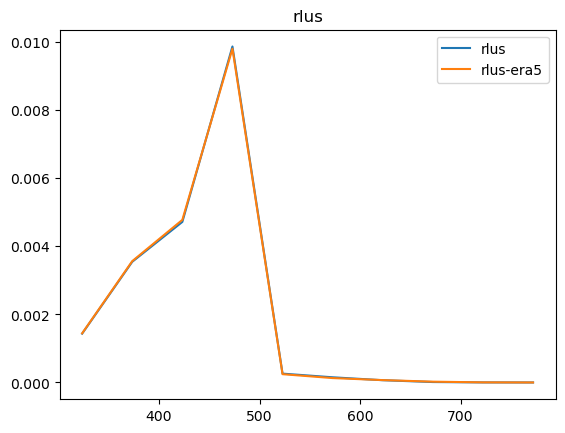

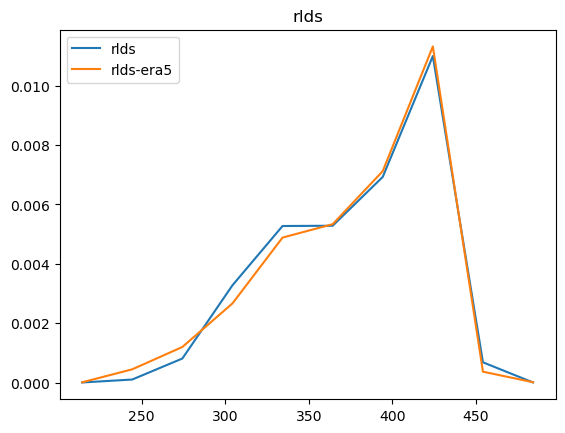

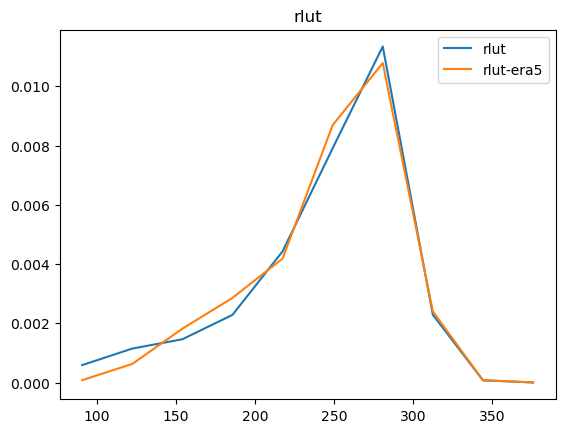

In [14]:
def moving_average(a, n=2):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

log_xaxis = []
log_yaxis = ['ps', 'pr', 'rsds']
    
for var in varlist:
    n_barra2, bins_barra2 = np.histogram(ds_barra2[var], density=True)
    n_era5, bins_era5 = np.histogram(ds_era5_regrid[barra2era_map[var]], bins=bins_barra2, density=True)

    plt.figure()
    plt.plot(moving_average(bins_barra2), n_barra2, label=var)
    plt.plot(moving_average(bins_era5), n_era5, label=f"{var}-era5")
    plt.legend()
    plt.title(var)
    if var in log_xaxis:
        plt.xscale('log')
    else:
        plt.xscale('linear')
    if var in log_yaxis:
        plt.yscale('log')
    else:
        plt.yscale('linear')

# Summary
This concludes the introduction on using BARRA-R2 and ERA5 data in PyEarthTools.
We have covered:

- the loading of BARRA-R2 and ERA5 data,
- combining hourly instantaneous and hourly averaged variables into a single dataset,
- regridding ERA5 to BARRA-R2 resolution,
- and plotting of mean maps and histograms of BARRA-R2 and ERA5.

The steps taken here to match BARRA-R2 to ERA5 will be useful when designing pipelines for training ML models.